In [1]:
import numpy as np
import xarray as xr
import sparselt.esmf
import sparselt.xr
import matplotlib.pyplot as plt

CHANGE_RESTART = False

In [2]:
def preproc(ds):
    ds = ds.assign({'tile': ds.encoding['source'][-4]})
    # we might need to tweak this a bit further, depending on the actual data layout
    return ds

In [3]:
res_path = './'+'/RESTART/'
cache_path = './'+'/CACHE/'

ds=xr.open_mfdataset([cache_path + 'fv_core.res.tile' + str(i) + '.nc' for i in range(1, 7)],  
                      # drop_variables = ['u0, v0, u, v, phis'],                    
                      concat_dim='tile',
                      combine='nested',
                      preprocess=preproc,
                      decode_times=False)#[['u_srf', 'v_srf']]# # Create a linear transformer object from an ESMF weights file
ds.load() 
ds

<xarray.Dataset>
Dimensions:  (xaxis_1: 96, xaxis_2: 97, yaxis_1: 97, yaxis_2: 96, zaxis_1: 32, Time: 1, tile: 6)
Coordinates:
  * xaxis_1  (xaxis_1) float64 1.0 2.0 3.0 4.0 5.0 ... 92.0 93.0 94.0 95.0 96.0
  * xaxis_2  (xaxis_2) float64 1.0 2.0 3.0 4.0 5.0 ... 93.0 94.0 95.0 96.0 97.0
  * yaxis_1  (yaxis_1) float64 1.0 2.0 3.0 4.0 5.0 ... 93.0 94.0 95.0 96.0 97.0
  * yaxis_2  (yaxis_2) float64 1.0 2.0 3.0 4.0 5.0 ... 92.0 93.0 94.0 95.0 96.0
  * zaxis_1  (zaxis_1) float64 1.0 2.0 3.0 4.0 5.0 ... 28.0 29.0 30.0 31.0 32.0
  * Time     (Time) float64 1.0
  * tile     (tile) <U1 '1' '2' '3' '4' '5' '6'
Data variables:
    u0       (tile, Time, zaxis_1, yaxis_1, xaxis_1) float32 24.1 ... 6.637
    v0       (tile, Time, zaxis_1, yaxis_2, xaxis_2) float32 -3.786e-14 ... -...
    u        (tile, Time, zaxis_1, yaxis_1, xaxis_1) float32 24.09 ... 6.626
    v        (tile, Time, zaxis_1, yaxis_2, xaxis_2) float32 -0.001056 ... -6...
    ua       (tile, Time, zaxis_1, yaxis_2, xaxis_1) float32 19.4 19.82 ... 3.88
    va       (tile, Time, zaxis_1, yaxis_2, xaxis_1) float32 0.0 0.0 ... 0.0 0.0
    W        (tile, Time, zaxis_1, yaxis_2, xaxis_1) float32 0.0 0.0 ... 0.0 0.0
    DZ       (tile, Time, zaxis_1, yaxis_2, xaxis_1) float32 -1.052e+04 ... -...
    T        (tile, Time, zaxis_1, yaxis_2, xaxis_1) float32 223.1 ... 296.7
    delp     (tile, Time, zaxis_1, yaxis_2, xaxis_1) float32 300.0 ... 777.0
    phis     (tile, Time, yaxis_2, xaxis_1) float32 351.8 326.4 ... 286.1 312.7
Attributes:
    NumFilesInSet:  1

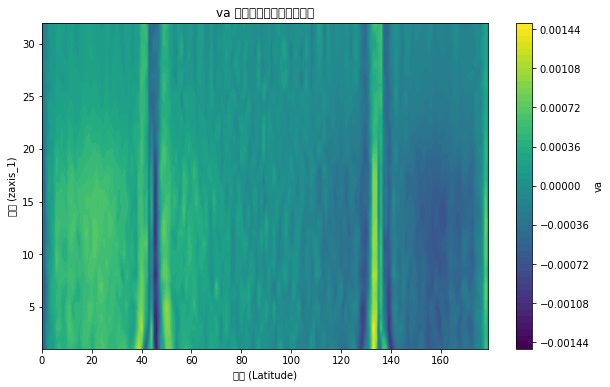

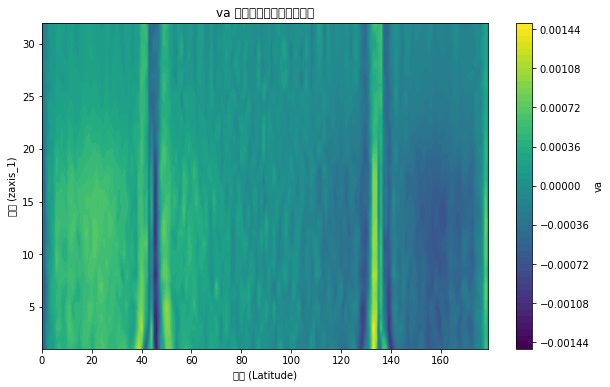

In [11]:
import matplotlib.pyplot as plt
import sparselt

# 定义目标变量
variables_to_plot = ['DZ', 'ua']

for var in variables_to_plot:
    # 提取变量数据
    var = 'va'
    temp = ds[var]
    

    
    # 应用重投影变换
    ds_new = sparselt.xr.apply(transform, temp.to_dataset())
    target = ds_new['va'][0,:,:,0]
    # ds_new 应该具有 (lat, lon, zaxis_1) 维度
    # 由于数据与经度无关，可以对经度维度进行平均
    
    # 绘制纬度-高度图像
    plt.figure(figsize=(10, 6))
    contour = target.plot.contourf(
        x='lat',
        y='zaxis_1',
        levels=50,
        cmap='viridis',
        add_colorbar=False
    )
    plt.colorbar(contour, label=var)
    plt.xlabel('纬度 (Latitude)')
    plt.ylabel('高度 (zaxis_1)')
    plt.title(f'{var} 关于纬度和高度的分布图')
    plt.show()


# We are dealing with ua in this part

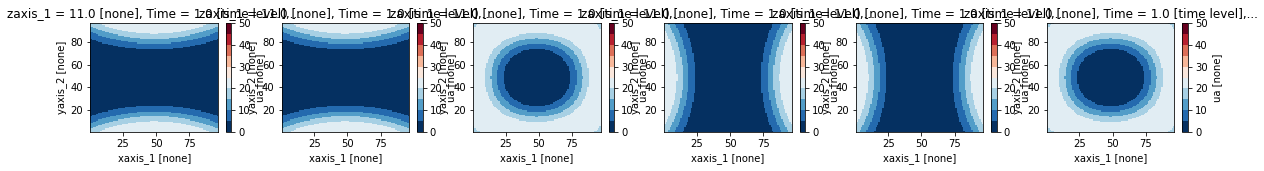

In [5]:
var_target = 'ua'

fig, ax = plt.subplots(1, 6, figsize=(20, 2))
for i in range(6):
    ds[var_target].isel(tile=i, zaxis_1=10).plot(ax=ax[i], levels=np.linspace(0, 50, 11), cmap='RdBu_r')
# print(ds)  

In [6]:

transform = sparselt.esmf.load_weights(
    cache_path + '/c96_to_180x360_weights.nc',                               # Generated by ESMF_RegridWeightGen
    input_dims=[('tile', 'yaxis_2', 'xaxis_1'), (6, 96, 96)],  # applied along input dimensions
    output_dims=[('lat', 'lon'), (180, 360)],           # result dimensions
)

### Apply the transform to ds
temp = ds[var_target]
temp_np = temp.values
noise_mean, noise_sigma = 0, 0.01
temp_np_with_noise = temp_np #+ #np.random.normal(noise_mean, noise_sigma, size=temp_np.shape) 
temp.data = temp_np_with_noise #temp_np

print(type(temp))

ds_new = sparselt.xr.apply(transform, temp.to_dataset())


<class 'xarray.core.dataarray.DataArray'>


In [9]:
plt.figure()
ds_new[var_target].isel(Time=0, zaxis_1=2).plot(levels=np.linspace(0, 50, 10))


IndexError: index 5 is out of bounds for axis 0 with size 1

<Figure size 432x288 with 0 Axes>

In [28]:
print(ds_new[var_target].isel(Time=0, zaxis_1=10))

<xarray.DataArray 'ua' (lat: 180, lon: 360)>
array([[0.02975631, 0.02975631, 0.02975631, ..., 0.02975631, 0.02975631,
        0.02975631],
       [0.11190148, 0.11168494, 0.11144646, ..., 0.11242479, 0.11227094,
        0.11209665],
       [0.27708537, 0.27600134, 0.2748075 , ..., 0.27970507, 0.27893489,
        0.27806239],
       ...,
       [0.27706577, 0.27598145, 0.2747873 , ..., 0.27968617, 0.27891578,
        0.27804305],
       [0.11183877, 0.11162221, 0.11138371, ..., 0.1123621 , 0.11220824,
        0.11203395],
       [0.02968901, 0.02968901, 0.02968901, ..., 0.02968901, 0.02968901,
        0.02968901]])
Coordinates:
    zaxis_1  float64 11.0
    Time     float64 1.0
Dimensions without coordinates: lat, lon
Attributes:
    long_name:  ua
    units:      none
    checksum:      6D9C264894DFB


In [22]:
u0 = 100
b = 2
n = 1
a = 6371e3  
up = 1.0
R = a / 10  

# Define the center of the perturbation (40°N, 20°E)
phi_c = np.deg2rad(40)
lambda_c = np.deg2rad(20)


def zonal_u(u0, phi, eta):
    return -u0*np.log(eta)*np.exp(-(np.log(eta)/b)**2)*(np.sin(2 * phi)**(2*n))

ds_new
print(ds_new['ua'].shape)

(1, 32, 180, 360)


In [23]:
#change ds_newx to change ua
lat = ds_new.coords['lat'].values - 89.5
lon = ds_new.coords['lon'].values
phi = np.deg2rad(lat)

zaxis_1 = ds_new.coords['zaxis_1'].values
eta = zaxis_1 / np.max(zaxis_1)

ua = ds_new['ua'].values

eta_grid, phi_grid, lon_grid = np.meshgrid(eta, phi, lon, indexing='ij')
ua_values = np.expand_dims(zonal_u(u0, phi_grid, eta_grid), axis=0)

r = a * np.arccos(np.sin(phi_c) * np.sin(phi_grid) + np.cos(phi_c) * np.cos(phi_grid) * np.cos(lon_grid - lambda_c))
u_perturbation = np.expand_dims(up * np.exp(-(r / R) ** 2), axis=0)#add a axis meaning time along 0

print(ua_values.shape)
print(u_perturbation.shape)

ua_values = ds_new[var_target] + u_perturbation #this will not change the base state
print(ua_values.shape)
print(ds_new[var_target].shape)
ds_new[var_target].loc[:] = ua_values


(1, 32, 180, 360)
(1, 32, 180, 360)
(1, 32, 180, 360)
(1, 32, 180, 360)


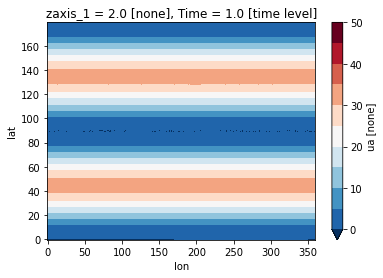

In [24]:
plt.figure()
ds_new[var_target].isel(Time=0, zaxis_1=1).plot(levels=np.linspace(0, 50, 11))


In [25]:


transform = sparselt.esmf.load_weights(
    cache_path + '/180x360_to_c96_weights.nc',                               # Generated by ESMF_RegridWeightGen
    input_dims=[('lat', 'lon'), (180, 360)],  # applied along input dimensions
    output_dims=[('tile', 'yaxis_2', 'xaxis_1'), (6, 96, 96)],           # result dimensions
)

# # # # Apply the transform to ds
ds_newx = sparselt.xr.apply(transform, ds_new[var_target].to_dataset())


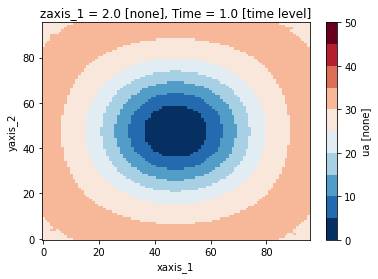

In [26]:

plt.figure()
ds_newx[var_target].isel(tile=2, zaxis_1=1).plot(levels=np.linspace(0, 50, 11), cmap='RdBu_r')

# ds.to_netcdf(cache_path)

In [27]:
for i in range(1, 7):
    ds_temp=xr.open_dataset(res_path + 'fv_core.res.tile' + str(i) + '.nc')
    print(ds_temp)
    print(ds_temp[var_target].values.shape)
    print(ds_newx[var_target].isel(tile=i-1).values.shape)

    ds_temp[var_target].values = ds_newx[var_target].isel(tile=i-1).values
    ds_temp.to_netcdf(cache_path  + 'fv_core.res.tile' + str(i) + '.nc')
    if CHANGE_RESTART:
        ds_temp.to_netcdf(res_path  + 'fv_core.res.tile' + str(i) + '.nc')
'''
    ds_c0=xr.open_dataset(res_path + 'fv_core.res.tile' + str(i) + '.nc')
    ds_c1=xr.open_dataset(cache_path + 'fv_core.res.tile' + str(i) + '.nc')

    print((ds_c0[var_target] - ds_c1[var_target]))
    ds_c0.close()
    ds_c1.close()
'''

    

<xarray.Dataset>
Dimensions:  (xaxis_1: 96, xaxis_2: 97, yaxis_1: 97, yaxis_2: 96, zaxis_1: 32, Time: 1)
Coordinates:
  * xaxis_1  (xaxis_1) float64 1.0 2.0 3.0 4.0 5.0 ... 92.0 93.0 94.0 95.0 96.0
  * xaxis_2  (xaxis_2) float64 1.0 2.0 3.0 4.0 5.0 ... 93.0 94.0 95.0 96.0 97.0
  * yaxis_1  (yaxis_1) float64 1.0 2.0 3.0 4.0 5.0 ... 93.0 94.0 95.0 96.0 97.0
  * yaxis_2  (yaxis_2) float64 1.0 2.0 3.0 4.0 5.0 ... 92.0 93.0 94.0 95.0 96.0
  * zaxis_1  (zaxis_1) float64 1.0 2.0 3.0 4.0 5.0 ... 28.0 29.0 30.0 31.0 32.0
  * Time     (Time) float64 1.0
Data variables:
    u0       (Time, zaxis_1, yaxis_1, xaxis_1) float32 ...
    v0       (Time, zaxis_1, yaxis_2, xaxis_2) float32 ...
    u        (Time, zaxis_1, yaxis_1, xaxis_1) float32 ...
    v        (Time, zaxis_1, yaxis_2, xaxis_2) float32 ...
    ua       (Time, zaxis_1, yaxis_2, xaxis_1) float32 ...
    va       (Time, zaxis_1, yaxis_2, xaxis_1) float32 ...
    W        (Time, zaxis_1, yaxis_2, xaxis_1) float32 ...
    DZ       (Time, z

"\n    ds_c0=xr.open_dataset(res_path + 'fv_core.res.tile' + str(i) + '.nc')\n    ds_c1=xr.open_dataset(cache_path + 'fv_core.res.tile' + str(i) + '.nc')\n\n    print((ds_c0[var_target] - ds_c1[var_target]))\n    ds_c0.close()\n    ds_c1.close()\n"

In [58]:
#print(ds_c0[var_target])
#print(ds_c0['va'])

In [59]:
# ds = xr.open_dataset(workdir + 'fv_core.res.tile1.nc')

In [60]:
# ds['ua'].isel(Time=0, zaxis_1=31).plot()

In [61]:
# # https://public.websites.umich.edu/~cjablono/DCMIP-2012_TestCaseDocument_v1.7.pdf
# #parameters
# z_top = 44000 # m
# p_top = 2.26 #hPa
# X = 1
# a_ref = 6.37122 * 10**6
# omega_ref = 7.292 * 10**(-5)
# a = a_ref/X
# omega = omega_ref/X

# g = 9.80616
# p_s = 1000
# p_0 = 1000 # hPa

# ita_0 = 0.252
# ita_t = 0.2
# ita_s = 1

# u_0 = 35
# u_p = 1
# pi = np.pi
# lambda_c = pi/9
# phi_c = 2*pi/9
# R = a/10
# T_0 = 288
# gamma = 0.005 # K/m
# deltaT = 4.8 * 10**5 


# c_p = 1004.5
# c_v = 717.5
# R_d = 287.0
# R_v = 461.5
# kappa = 2/7
# epsilon = 0.622
# rho_water = 1000



In [62]:
# p_target = np.asarray([1000, 850, 700, 500, 200, 100, 10])
# ita = p_target/p_s
# phi = np.linspace(-pi, pi, 181) 
# lambda_in = np.linspace(0, pi, 361) 
# ita_v = (ita - ita_0) * pi / 2


In [63]:
# def setup_grid(nlat, nlon, nlev):
#     init_array = np.zeros(nlat, nlon, nlev)
#     return init_array


# r = a * np.arccos(np.sin(phi_c)*np.sin(phi) + np.cos(phi_c)*np.cos(phi)*np.cos(lambda_in - lambda_c)) # great circle distance from the perturbation
# u = u_0 * (np.cos(ita_v))**(3/2) * (np.sin(2*phi))**2 + u_p * np.exp(-(r/R)**2)
# v = 0; w = 0; omega = 0

# if 1>=ita>=ita_t:
#     T_bar = T_0 * ita**(R_d * gamma / g)
# elif ita_t > ita:
#     T_bar = T_0 * ita**(R_d * gamma / g) + deltaT * (ita_t - ita)**5


# T = T_bar + (3*ita*pi*u_0)/(4*R_d) * np.sin(ita_v)* (np.cos(ita_v))**(1/2) * \
#     (2*u_0* (np.cos(ita_v))**(3/2) * (-2 * (np.sin(phi))**6 * ( (np.cos(phi))**2 + 1/3) + 10/63) + \
#      a*omega*(8/5 * (np.cos(phi))**3 * ( (np.sin(phi))**2 + 2/3) - pi/4 ))

# rho = p/(R_d * T)
